In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



Датасет EMINST

In [14]:
from torch.utils.data import Dataset
class FixedEMNIST(Dataset):
    """EMNIST с правильной последовательной нумерацией классов"""
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        self.classes = original_dataset.classes
        
        # Получаем оригинальные метки
        original_targets = original_dataset.targets
        
        # Находим уникальные метки (они уже в правильном порядке)
        unique_labels = sorted(set(original_targets.numpy()))
        
        # Создаем маппинг: старый индекс -> новый индекс (0-46)
        self.mapping = {old: new for new, old in enumerate(unique_labels)}
        
        # Применяем маппинг
        self.targets = torch.tensor([self.mapping[t.item()] for t in original_targets])
        print(f"Mетки: от {min(self.targets)} до {max(self.targets)}")
        print(f"Уникальных классов: {len(set(self.targets.numpy()))}")
    
    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        return x, self.targets[idx]
    
    def __len__(self):
        return len(self.dataset)
    
transform = transforms.Compose([
    transforms.ToTensor(), #функция totensor трансформирует выборку в тензор вида [0,1]
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала (нормализация до [-1,1])
])
train_full = FixedEMNIST(torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split = "balanced"
))
test_ds = FixedEMNIST(torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split = "balanced"
))

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

Mетки: от 0 до 46
Уникальных классов: 47
Mетки: от 0 до 46
Уникальных классов: 47
classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800




```
# Вместо обработки всех 100,000 картинок сразу,
# мы берем по 32 картинки (батч) за раз
batch_size = 32
for batch in dataloader:
    # 32 картинки за раз
    # Делаем 3125 шагов вместо 1 огромного шага
```



In [3]:
# Размер батча подстроим под наличие GPU
# батч - скорость обучения(количество примеров, обрабатываемых за раз)
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

In [4]:
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size #разбивка на трейн и тест выборки, указание размеров

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
) #итератор, подает данные батчами

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


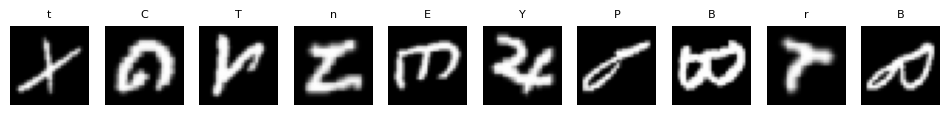

In [5]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [20]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [7]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [17]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1843, acc=0.6530 | val loss=0.8060, acc=0.7461
epoch 02/20 | train loss=0.6799, acc=0.7823 | val loss=0.6436, acc=0.7922
epoch 03/20 | train loss=0.5772, acc=0.8092 | val loss=0.5870, acc=0.8031
epoch 04/20 | train loss=0.5196, acc=0.8257 | val loss=0.5567, acc=0.8202
epoch 05/20 | train loss=0.4812, acc=0.8344 | val loss=0.5347, acc=0.8258
epoch 06/20 | train loss=0.4513, acc=0.8429 | val loss=0.5322, acc=0.8273
epoch 07/20 | train loss=0.4290, acc=0.8488 | val loss=0.5318, acc=0.8251
epoch 08/20 | train loss=0.4076, acc=0.8536 | val loss=0.5231, acc=0.8326
epoch 09/20 | train loss=0.3914, acc=0.8583 | val loss=0.5227, acc=0.8352
epoch 10/20 | train loss=0.3760, acc=0.8623 | val loss=0.5448, acc=0.8297
epoch 11/20 | train loss=0.3662, acc=0.8644 | val loss=0.5198, acc=0.8363
epoch 12/20 | train loss=0.3530, acc=0.8689 | val loss=0.5395, acc=0.8310
epoch 13/20 | train loss=0.3427, acc=0.8716 | val loss=0.5243, acc=0.8380
epoch 14/20 | train loss=0.3344, acc=0

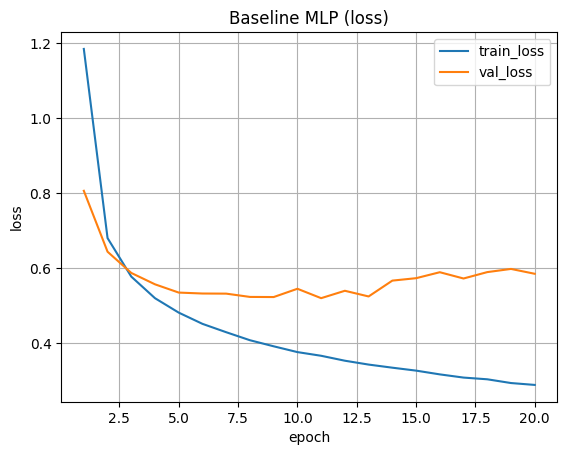

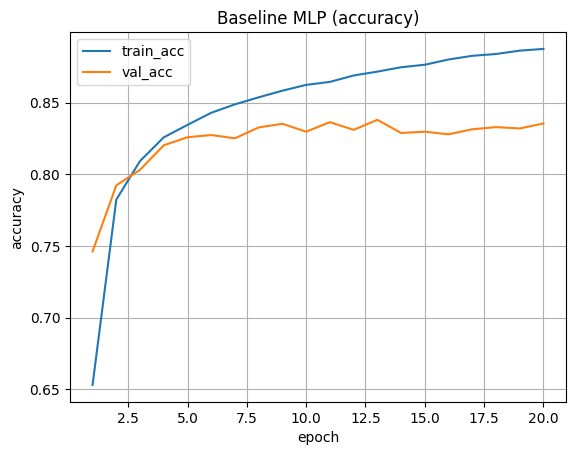

In [21]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=1.5678, acc=0.5446 | val loss=0.8845, acc=0.7284
epoch 02/20 | train loss=1.0605, acc=0.6750 | val loss=0.7282, acc=0.7724
epoch 03/20 | train loss=0.9504, acc=0.7012 | val loss=0.6737, acc=0.7805
epoch 04/20 | train loss=0.8934, acc=0.7169 | val loss=0.6362, acc=0.7934
epoch 05/20 | train loss=0.8577, acc=0.7274 | val loss=0.6210, acc=0.7959
epoch 06/20 | train loss=0.8325, acc=0.7331 | val loss=0.5995, acc=0.8040
epoch 07/20 | train loss=0.8224, acc=0.7365 | val loss=0.5941, acc=0.8027
epoch 08/20 | train loss=0.8059, acc=0.7395 | val loss=0.5937, acc=0.8074
epoch 09/20 | train loss=0.7924, acc=0.7442 | val loss=0.5904, acc=0.8075
epoch 10/20 | train loss=0.7870, acc=0.7444 | val loss=0.5737, acc=0.8130
epoch 11/20 | train loss=0.7734, acc=0.7493 | val loss=0.5609, acc=0.8148
epoch 12/20 | train loss=0.7639, acc=0.7521 | val loss=0.5607, acc=0.8137
epoch 13/20 | train loss=0.7559, acc=0.7530 | val loss=0.5525, acc=0.8200
epoch 14/20 | train loss=0.7534, acc=0

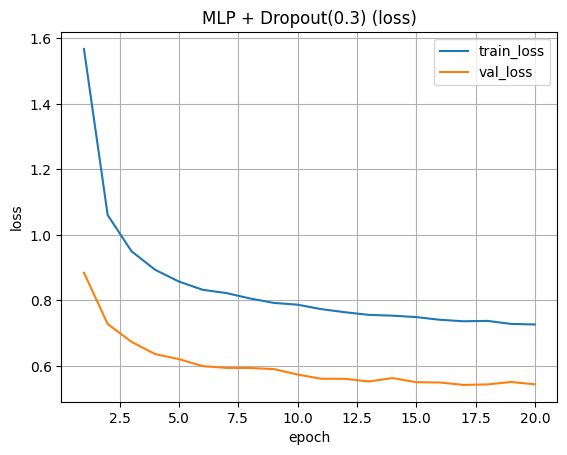

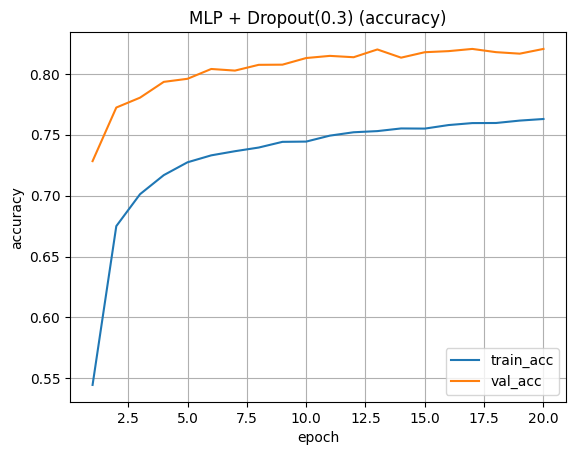

Dropout test: loss=0.5616, acc=0.8145


In [22]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [24]:

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/50 | train loss=1.3149, acc=0.6270 | val loss=0.6847, acc=0.7847
epoch 02/50 | train loss=0.8671, acc=0.7256 | val loss=0.5832, acc=0.8129
epoch 03/50 | train loss=0.7711, acc=0.7520 | val loss=0.5406, acc=0.8185
epoch 04/50 | train loss=0.7229, acc=0.7642 | val loss=0.5177, acc=0.8256
epoch 05/50 | train loss=0.6856, acc=0.7741 | val loss=0.4925, acc=0.8356
epoch 06/50 | train loss=0.6672, acc=0.7799 | val loss=0.4828, acc=0.8369
epoch 07/50 | train loss=0.6440, acc=0.7856 | val loss=0.4718, acc=0.8387
epoch 08/50 | train loss=0.6247, acc=0.7927 | val loss=0.4672, acc=0.8393
epoch 09/50 | train loss=0.6149, acc=0.7948 | val loss=0.4611, acc=0.8426
epoch 10/50 | train loss=0.6052, acc=0.7975 | val loss=0.4578, acc=0.8436
epoch 11/50 | train loss=0.5960, acc=0.7993 | val loss=0.4505, acc=0.8457
epoch 12/50 | train loss=0.5850, acc=0.8041 | val loss=0.4544, acc=0.8440
epoch 13/50 | train loss=0.5717, acc=0.8066 | val loss=0.4433, acc=0.8472
epoch 14/50 | train loss=0.5685, acc=0

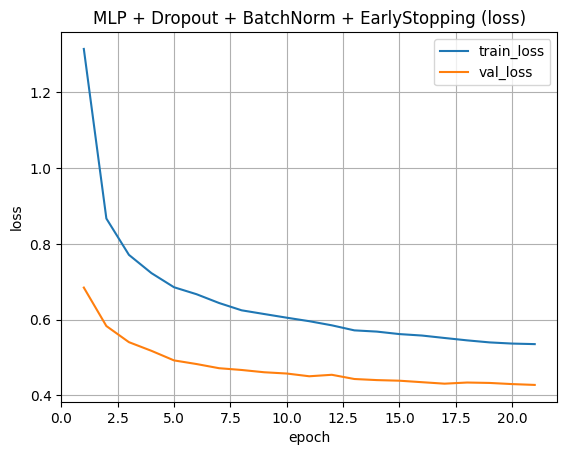

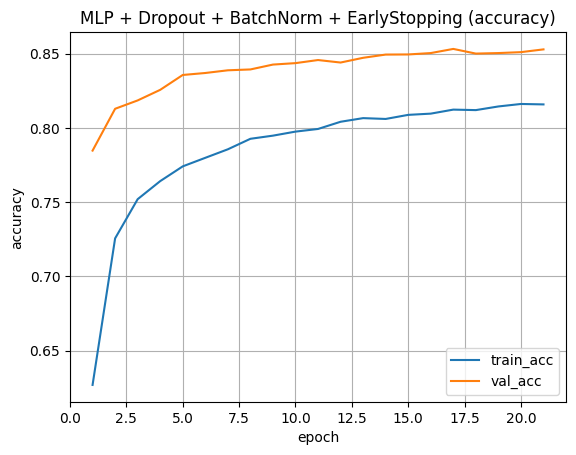

Combo test: loss=0.4552, acc=0.8467


In [25]:

set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [30]:

results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    # "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.0675
  dropout: test_acc=0.8145
    combo: test_acc=0.8467


Эксперименты

epoch 01/2 | train loss=3.5946, acc=0.0443 | val loss=3.4308, acc=0.0536
epoch 02/2 | train loss=3.3870, acc=0.0624 | val loss=3.3590, acc=0.0656


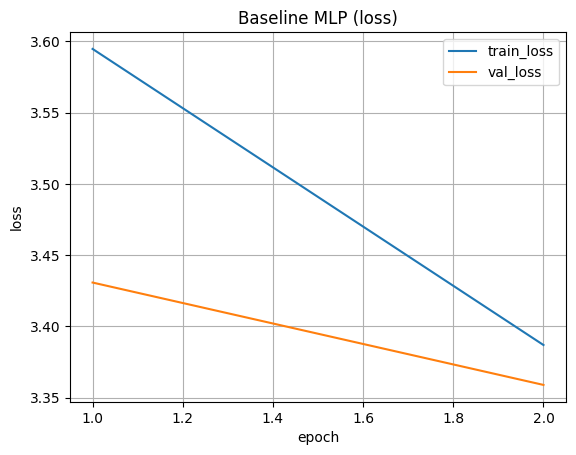

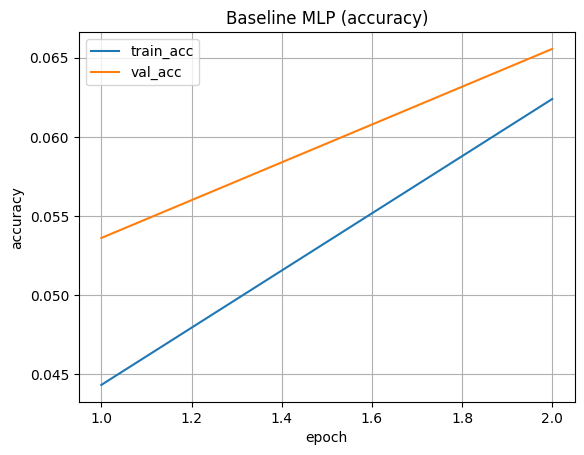

In [29]:
set_seed(42)
baseline = MLP(hidden_dims=(2, 5), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=2,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/4 | train loss=3.8064, acc=0.0269 | val loss=3.7191, acc=0.0487
epoch 02/4 | train loss=3.7590, acc=0.0307 | val loss=3.6928, acc=0.0437
epoch 03/4 | train loss=3.7497, acc=0.0324 | val loss=3.6962, acc=0.0439
epoch 04/4 | train loss=3.7455, acc=0.0341 | val loss=3.6612, acc=0.0500


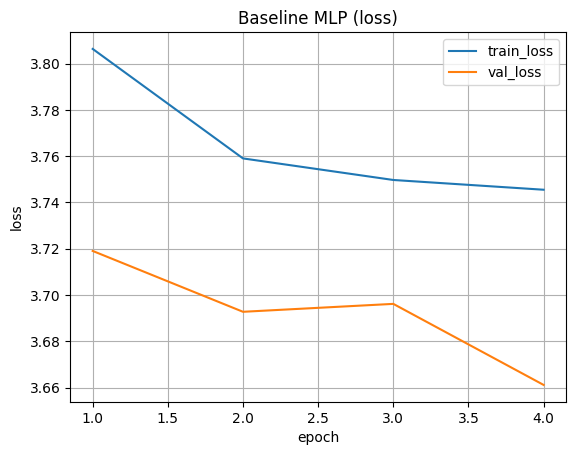

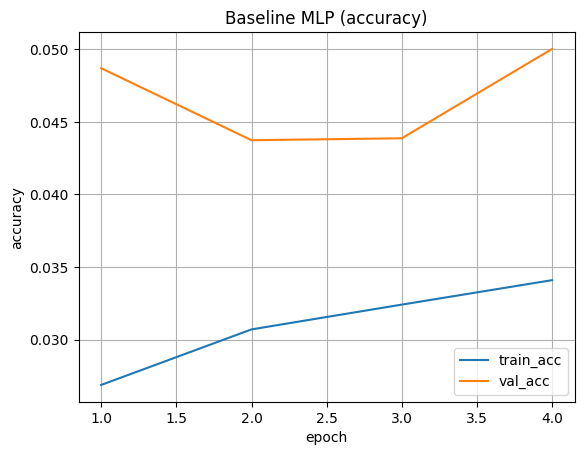

In [32]:
set_seed(42)
baseline = MLP(hidden_dims=(2, 5), dropout_p=0.5, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=4,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/4 | train loss=3.3718, acc=0.0842 | val loss=3.0198, acc=0.1234
epoch 02/4 | train loss=2.9499, acc=0.1343 | val loss=2.8687, acc=0.1485
epoch 03/4 | train loss=2.8750, acc=0.1496 | val loss=2.8213, acc=0.1645
epoch 04/4 | train loss=2.8426, acc=0.1615 | val loss=2.7905, acc=0.1677


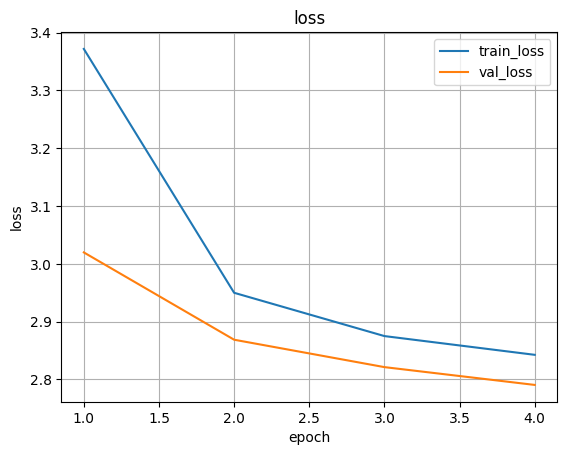

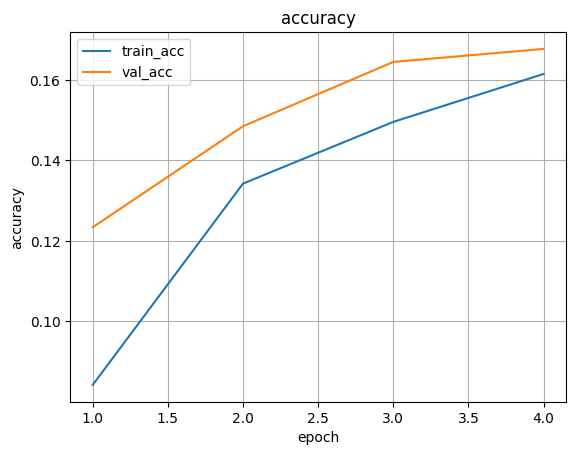

In [ ]:
set_seed(42)
baseline = MLP(hidden_dims=(2, 5, 4), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=4,
    early_stopping=None
)

plot_history(history_baseline, title="")

In [40]:
set_seed(42)
best_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=1e-1)

es = EarlyStopping(patience=5, min_delta=0.0005)

history_combo = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

epoch 01/20 | train loss=1.2098, acc=0.6355 | val loss=0.9466, acc=0.6968
epoch 02/20 | train loss=0.8835, acc=0.7240 | val loss=0.7793, acc=0.7513
epoch 03/20 | train loss=0.8188, acc=0.7438 | val loss=0.7304, acc=0.7676
epoch 04/20 | train loss=0.7648, acc=0.7572 | val loss=0.6721, acc=0.7887
epoch 05/20 | train loss=0.7348, acc=0.7647 | val loss=0.6579, acc=0.7928
epoch 06/20 | train loss=0.7064, acc=0.7725 | val loss=0.7178, acc=0.7846
epoch 07/20 | train loss=0.6893, acc=0.7781 | val loss=0.6659, acc=0.7821
epoch 08/20 | train loss=0.6716, acc=0.7830 | val loss=0.6332, acc=0.8086
epoch 09/20 | train loss=0.6587, acc=0.7867 | val loss=0.6721, acc=0.7946
epoch 10/20 | train loss=0.6407, acc=0.7914 | val loss=0.6373, acc=0.8064
epoch 11/20 | train loss=0.6314, acc=0.7943 | val loss=0.6395, acc=0.8035
epoch 12/20 | train loss=0.6204, acc=0.7955 | val loss=0.6949, acc=0.7852
epoch 13/20 | train loss=0.6126, acc=0.8005 | val loss=0.6743, acc=0.7978
EarlyStopping: остановка на эпохе 13. 

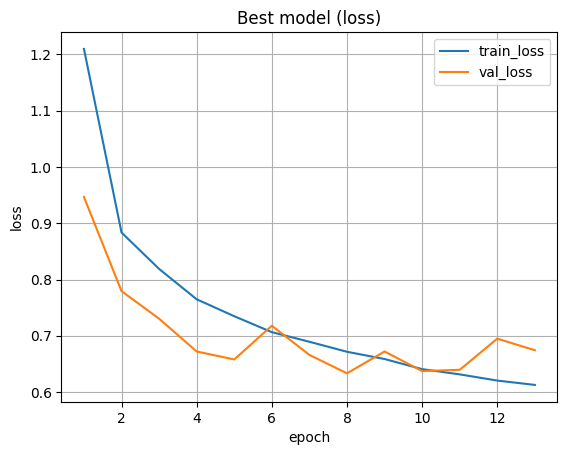

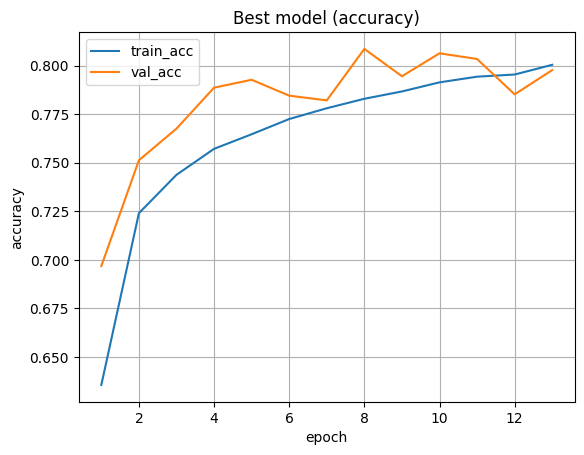

In [52]:
epochs = np.arange(1, len(history_combo["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history_combo["train_loss"], label="train_loss")
plt.plot(epochs, history_combo["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(("Best model"+ " (loss)"))
plt.legend()
plt.grid(True)
plt.savefig('./artifacts/curves_best.png.png')
plt.show()

plt.figure()
plt.plot(epochs, history_combo["train_acc"], label="train_acc")
plt.plot(epochs, history_combo["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(("Best model" + " (accuracy)"))
plt.legend()
plt.grid(True)
plt.savefig('./artifacts/curves_best.png')
plt.show()

In [41]:
tmp_path = './artifacts/best_model.pt'
torch.save(best_model.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')

saved to ./artifacts/best_model.pt size: 971573 bytes


In [43]:
import json
from pathlib import Path

best_model_config = {
 
    "Архитектура": {
        "type": "MLP",
        "hidden_dims": [256, 128],
        "dropout_p": 0.0,
        "use_batchnorm": True,
        "num_classes": 47,
        "input_dim": 784,
    },
    "training_config": {
        "optimizer": "Adam",
        "learning_rate": 0.1,
        "criterion": "CrossEntropyLoss",
        "batch_size": 256,
        "epochs": 20,
        "early_stopping": 5,
    },
    "dataset": "EMNIST",
    "seed": 42,
}

artifacts_dir = Path('./artifacts')
config_path = artifacts_dir / 'best_config.json'

with config_path.open("w", encoding="utf-8") as f:
    json.dump(best_model_config, f, ensure_ascii=False, indent=2)

In [7]:

import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

from torch.utils.data import DataLoader, TensorDataset, random_split

@dataclass
class DataConfig:
    dataset_name: str = "KMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.15
    num_workers: int = 0
    fast_mode: bool = True
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

def _try_load_torchvision_dataset(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms

    name = cfg.dataset_name.upper().strip()

    if name in {"KMNIST", "EMNIST"}:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    if name == "KMNIST":
        train_ds = datasets.KMNIST(root=cfg.data_dir, train=True, download=True, transform=transform)
        test_ds  = datasets.KMNIST(root=cfg.data_dir, train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 10, "torchvision.KMNIST (28x28, 10 классов)"

    if name == "EMNIST":
        train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
        test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"

    if name == "CIFAR10":
        transform_cifar = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
        ])
        train_ds = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=transform_cifar)
        test_ds  = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=transform_cifar)
        return train_ds, test_ds, 32 * 32 * 3, 10, "torchvision.CIFAR10 (32x32x3, 10 классов)"

    raise ValueError(f"Unknown torchvision dataset_name={cfg.dataset_name!r}")

def _load_digits_fallback(cfg: DataConfig):
    """Запасной вариант без torchvision: sklearn.datasets.load_digits."""
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split

    digits = load_digits()
    X = digits.data.astype(np.float32)     # (n, 64)
    y = digits.target.astype(np.int64)     # (n,)

    # Нормируем в [0, 1]
    X = X / (X.max() + 1e-8)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
    return train_ds, test_ds, X.shape[1], int(y.max() + 1), "sklearn.load_digits (8x8 => 64 признака, 10 классов) [fallback]"

def load_data(cfg: DataConfig):
    try:
        train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset(cfg)
    except Exception as e:
        print("torchvision недоступен или датасет не загрузился. Используем fallback digits. Причина:", repr(e))
        cfg.dataset_name = "DIGITS_FALLBACK"
        train_ds, test_ds, input_dim, num_classes, info = _load_digits_fallback(cfg)

    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds
        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)

Device: cpu
Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47


In [8]:
def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x

print("x_flat:", x_flat.shape)

x: <class 'torch.Tensor'> torch.Size([128, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([128]) torch.int64
x_flat: torch.Size([128, 784])


In [9]:

class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden1: int = 256, hidden2: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(model)
print("Trainable params:", count_params(model))

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable params: 239919


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=6, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

    return history


def plot_history(hist, title=""):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

Epoch 01/6 | train loss 2.4787, acc 0.356 | val loss 1.6334, acc 0.538 | 1.3s
Epoch 02/6 | train loss 1.4534, acc 0.582 | val loss 1.3703, acc 0.613 | 1.2s
Epoch 03/6 | train loss 1.2441, acc 0.636 | val loss 1.2423, acc 0.646 | 1.2s
Epoch 04/6 | train loss 1.1175, acc 0.667 | val loss 1.1396, acc 0.663 | 1.3s
Epoch 05/6 | train loss 0.9988, acc 0.704 | val loss 1.0493, acc 0.699 | 1.2s
Epoch 06/6 | train loss 0.8981, acc 0.728 | val loss 0.9480, acc 0.721 | 1.3s


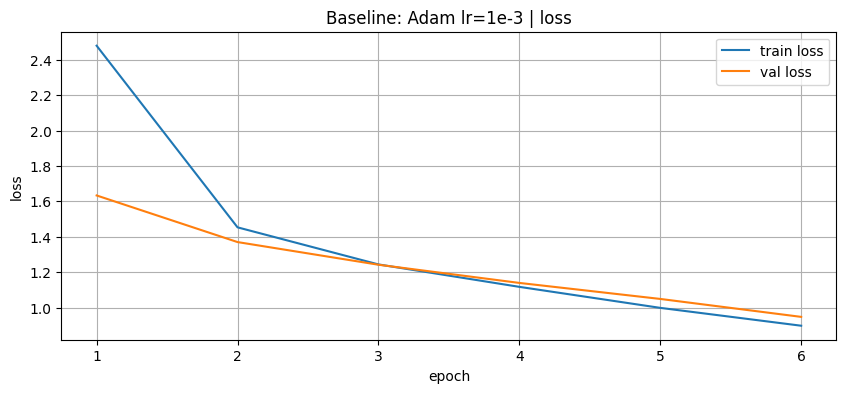

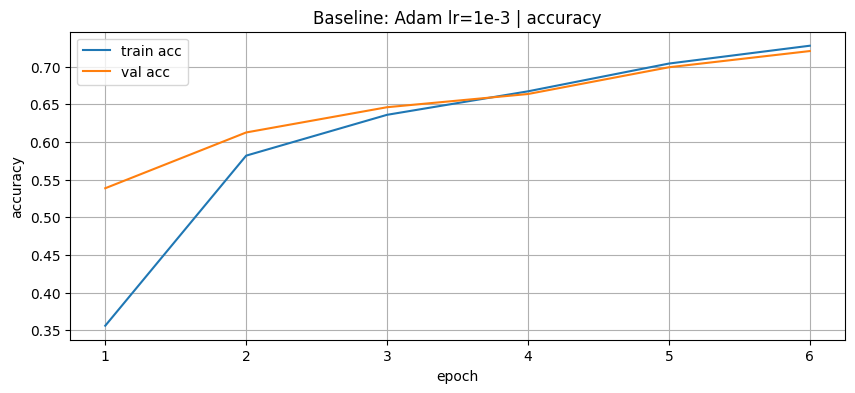

In [13]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def make_model():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

baseline_model = make_model()
baseline_opt = make_optimizer(baseline_model, kind="adam", lr=1e-3, weight_decay=0.0)

baseline_hist = fit(baseline_model, train_loader, val_loader, baseline_opt, criterion, epochs=EPOCHS)
plot_history(baseline_hist, title="Baseline: Adam lr=1e-3")


Experiment LR_high: Adam lr=0.1
Epoch 01/6 | train loss 19.1016, acc 0.022 | val loss 3.8708, acc 0.020 | 1.3s
Epoch 02/6 | train loss 3.8631, acc 0.019 | val loss 3.8682, acc 0.022 | 1.3s
Epoch 03/6 | train loss 3.8659, acc 0.021 | val loss 3.8651, acc 0.019 | 1.2s
Epoch 04/6 | train loss 3.8617, acc 0.022 | val loss 3.8630, acc 0.021 | 1.3s
Epoch 05/6 | train loss 3.8608, acc 0.021 | val loss 3.8613, acc 0.018 | 1.3s
Epoch 06/6 | train loss 3.8617, acc 0.023 | val loss 3.8618, acc 0.020 | 1.3s


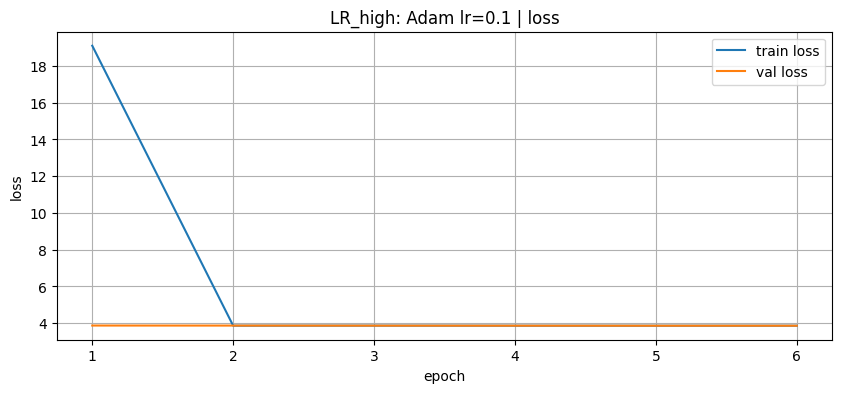

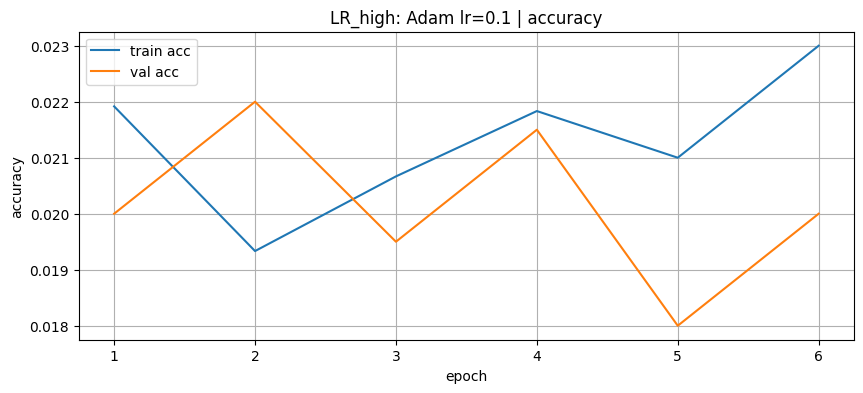


Experiment LR_ok: Adam lr=0.001
Epoch 01/6 | train loss 2.4562, acc 0.359 | val loss 1.6442, acc 0.534 | 1.3s
Epoch 02/6 | train loss 1.4587, acc 0.579 | val loss 1.4048, acc 0.594 | 1.3s
Epoch 03/6 | train loss 1.2618, acc 0.630 | val loss 1.2280, acc 0.643 | 1.3s
Epoch 04/6 | train loss 1.1229, acc 0.666 | val loss 1.1241, acc 0.681 | 1.2s
Epoch 05/6 | train loss 1.0068, acc 0.698 | val loss 1.0240, acc 0.686 | 1.2s
Epoch 06/6 | train loss 0.9113, acc 0.719 | val loss 0.9666, acc 0.704 | 1.2s


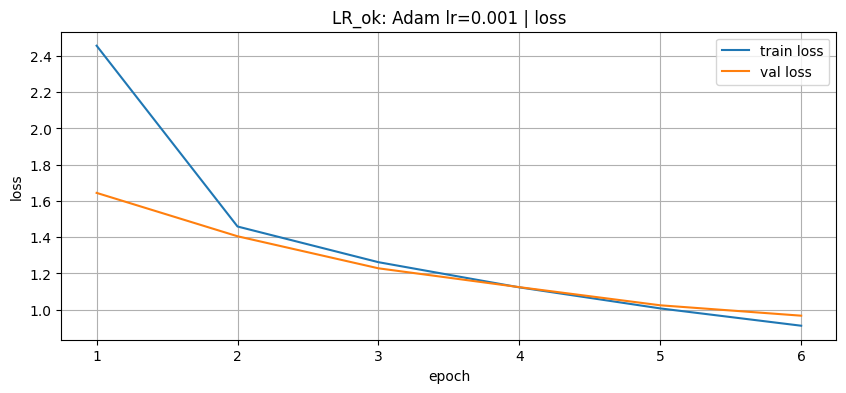

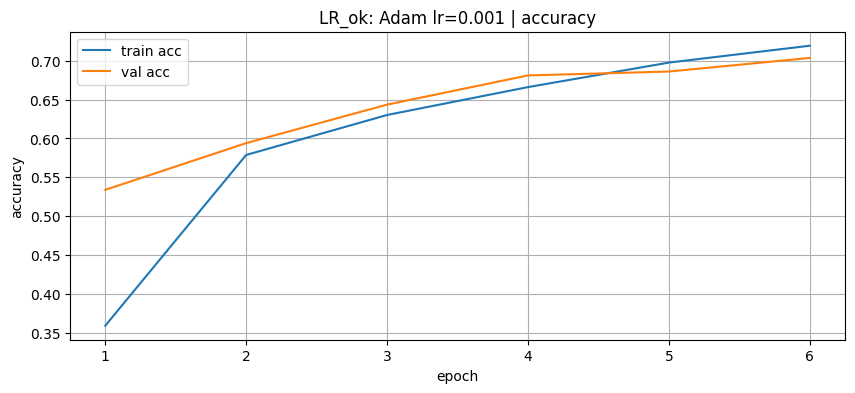


Experiment LR_low: Adam lr=1e-05
Epoch 01/6 | train loss 3.8425, acc 0.023 | val loss 3.8239, acc 0.036 | 1.3s
Epoch 02/6 | train loss 3.8046, acc 0.069 | val loss 3.7825, acc 0.088 | 1.3s
Epoch 03/6 | train loss 3.7572, acc 0.113 | val loss 3.7315, acc 0.124 | 1.2s
Epoch 04/6 | train loss 3.6998, acc 0.150 | val loss 3.6716, acc 0.149 | 1.3s
Epoch 05/6 | train loss 3.6335, acc 0.176 | val loss 3.6031, acc 0.170 | 1.2s
Epoch 06/6 | train loss 3.5590, acc 0.201 | val loss 3.5274, acc 0.206 | 1.2s


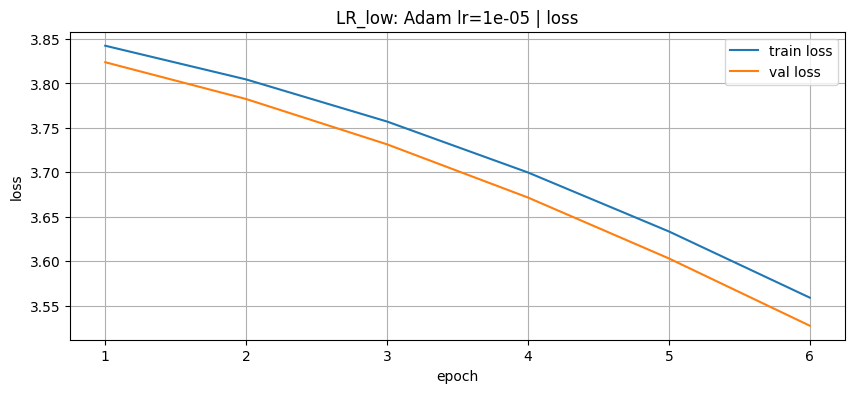

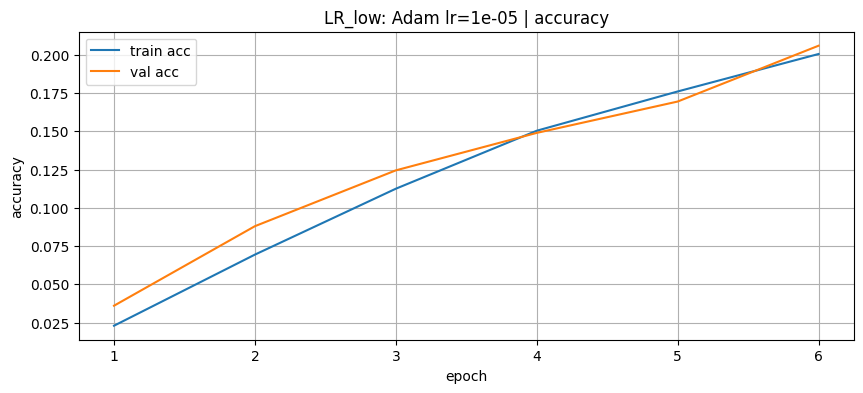

In [14]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("LR_high", 1e-1),
    ("LR_ok",   1e-3),
    ("LR_low",  1e-5),
]

results_lr = []
for name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=name, optimizer_kind="adam", lr=lr)
    results_lr.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")

In [5]:
rows = []
for r in results_lr:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_lr)

NameError: name 'results_lr' is not defined


Experiment OPT_Adam: Adam lr=1e-3
Epoch 01/6 | train loss 2.4959, acc 0.347 | val loss 1.6214, acc 0.535 | 1.3s
Epoch 02/6 | train loss 1.4501, acc 0.590 | val loss 1.3955, acc 0.589 | 1.3s
Epoch 03/6 | train loss 1.2580, acc 0.634 | val loss 1.2213, acc 0.634 | 1.3s
Epoch 04/6 | train loss 1.1183, acc 0.669 | val loss 1.1325, acc 0.663 | 1.2s
Epoch 05/6 | train loss 1.0051, acc 0.699 | val loss 1.0385, acc 0.690 | 1.3s
Epoch 06/6 | train loss 0.9087, acc 0.724 | val loss 0.9895, acc 0.699 | 1.2s


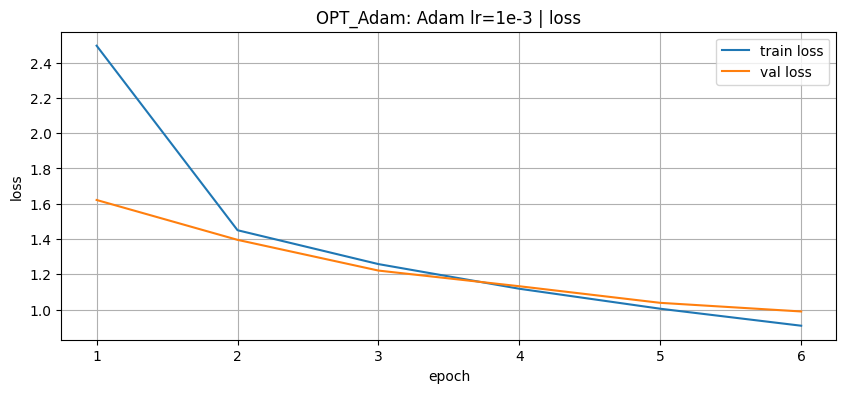

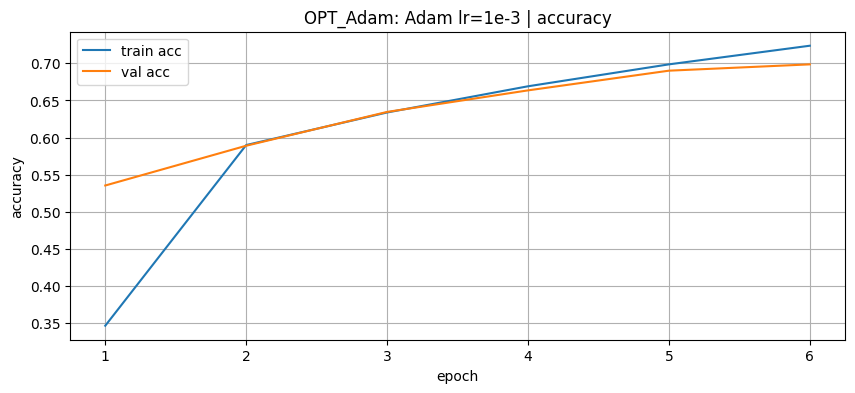


Experiment OPT_SGD: SGD lr=0.1 momentum=0.9
Epoch 01/6 | train loss 2.3154, acc 0.358 | val loss 1.4516, acc 0.567 | 1.3s
Epoch 02/6 | train loss 1.4391, acc 0.572 | val loss 1.5099, acc 0.557 | 1.3s
Epoch 03/6 | train loss 1.2486, acc 0.618 | val loss 1.1571, acc 0.652 | 1.2s
Epoch 04/6 | train loss 1.1187, acc 0.652 | val loss 1.1748, acc 0.650 | 1.3s
Epoch 05/6 | train loss 1.0351, acc 0.677 | val loss 1.2736, acc 0.641 | 1.2s
Epoch 06/6 | train loss 1.0483, acc 0.675 | val loss 1.2110, acc 0.655 | 1.2s


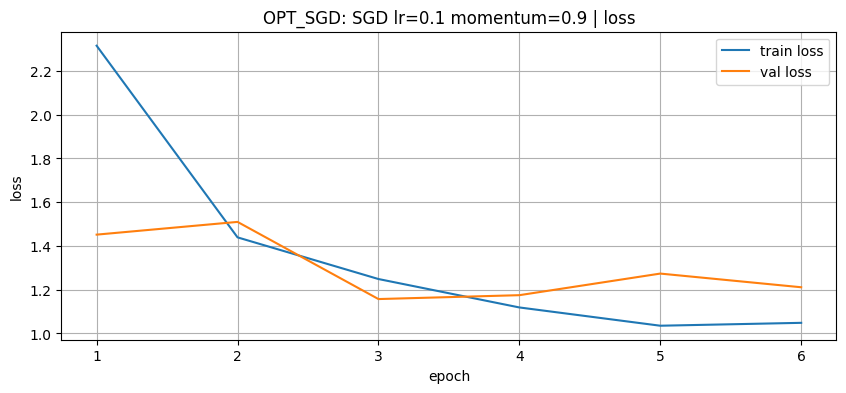

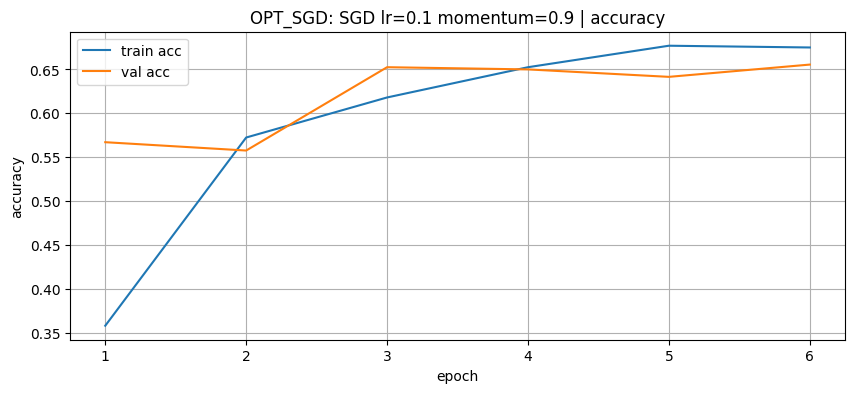

,exp_id,optimizer,lr,momentum,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,OPT_Adam,adam,0.001,NaN,0.0,6,0.6985,0.989545
1,OPT_SGD,sgd,0.100,0.9,0.0,6,0.6555,1.157058


In [ ]:

results_opt = []

print("\n" + "="*80)
print("Experiment OPT_Adam: Adam lr=1e-3")
res_adam = run_experiment(exp_id="OPT_Adam", optimizer_kind="adam", lr=1e-3)
results_opt.append(res_adam)
plot_history(res_adam["history"], title="OPT_Adam: Adam lr=1e-3")

print("\n" + "="*80)
print("Experiment OPT_SGD: SGD lr=0.1 momentum=0.9")
res_sgd = run_experiment(exp_id="OPT_SGD", optimizer_kind="sgd", lr=0.1, momentum=0.9)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="OPT_SGD: SGD lr=0.1 momentum=0.9")

rows = []
for r in results_opt:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_opt = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_opt)


Experiment OPT_Adam: Adam lr=1e-3
Epoch 01/6 | train loss 2.4454, acc 0.359 | val loss 1.7547, acc 0.499 | 1.3s
Epoch 02/6 | train loss 1.4685, acc 0.582 | val loss 1.3904, acc 0.588 | 1.3s
Epoch 03/6 | train loss 1.2518, acc 0.636 | val loss 1.2362, acc 0.628 | 1.3s
Epoch 04/6 | train loss 1.1087, acc 0.675 | val loss 1.1231, acc 0.677 | 1.3s
Epoch 05/6 | train loss 0.9966, acc 0.701 | val loss 1.0452, acc 0.690 | 1.3s
Epoch 06/6 | train loss 0.9036, acc 0.723 | val loss 0.9747, acc 0.717 | 1.3s


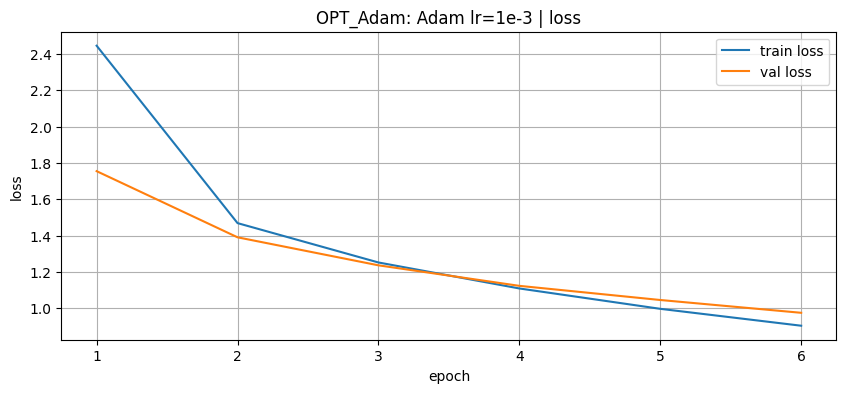

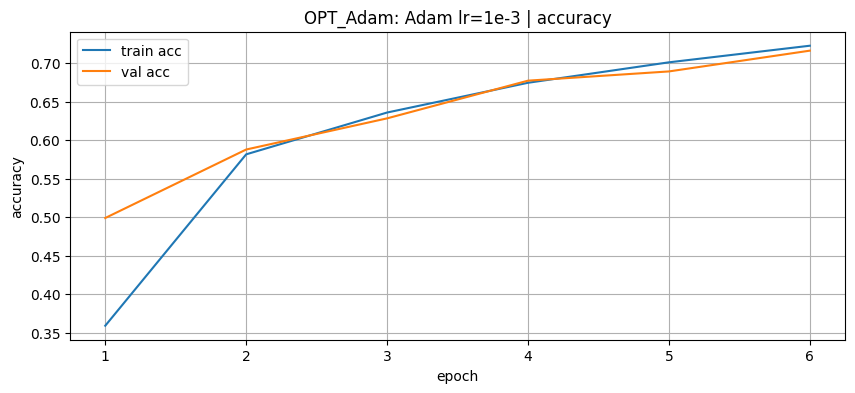


Experiment OPT_SGD: SGD lr=0.1 momentum=0.9
Epoch 01/6 | train loss 2.3407, acc 0.353 | val loss 1.5681, acc 0.531 | 1.3s
Epoch 02/6 | train loss 1.4052, acc 0.576 | val loss 1.3261, acc 0.600 | 1.3s
Epoch 03/6 | train loss 1.2248, acc 0.627 | val loss 1.1912, acc 0.647 | 1.3s
Epoch 04/6 | train loss 1.1268, acc 0.647 | val loss 1.2387, acc 0.634 | 1.3s
Epoch 05/6 | train loss 1.0403, acc 0.674 | val loss 1.2003, acc 0.647 | 1.4s
Epoch 06/6 | train loss 0.9886, acc 0.689 | val loss 1.1529, acc 0.662 | 1.2s


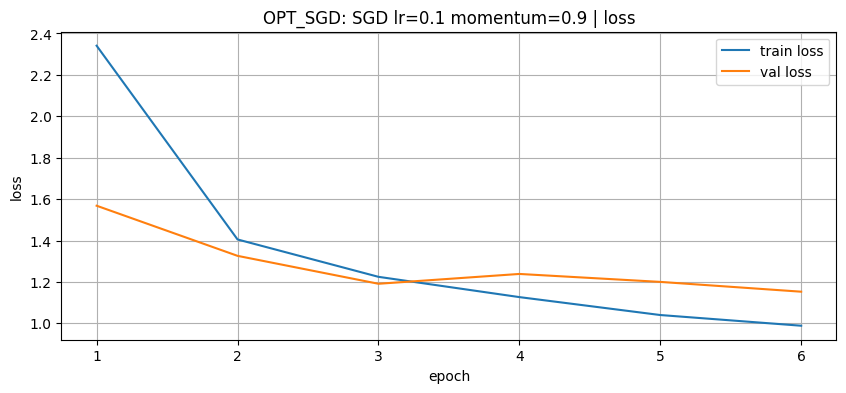

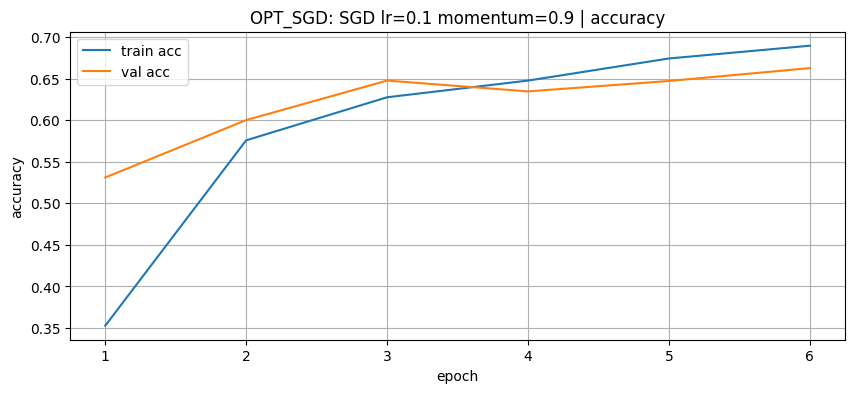

,exp_id,optimizer,lr,momentum,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,OPT_Adam,adam,0.001,NaN,0.0,6,0.7165,0.974746
1,OPT_SGD,sgd,0.100,0.9,0.0,6,0.6625,1.152930


In [73]:

results_opt = []

print("\n" + "="*80)
print("Experiment OPT_Adam: Adam lr=1e-3")
res_adam = run_experiment(exp_id="OPT_Adam", optimizer_kind="adam", lr=1e-3)
results_opt.append(res_adam)
plot_history(res_adam["history"], title="OPT_Adam: Adam lr=1e-3")

print("\n" + "="*80)
print("Experiment OPT_SGD: SGD lr=0.1 momentum=0.9")
res_sgd = run_experiment(exp_id="OPT_SGD", optimizer_kind="sgd", lr=0.1, momentum=0.9)
results_opt.append(res_sgd)
plot_history(res_sgd["history"], title="OPT_SGD: SGD lr=0.1 momentum=0.9")

rows = []
for r in results_opt:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_opt = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_opt)


Experiment WD_0: Adam lr=1e-3 weight_decay=0.0
Epoch 01/6 | train loss 2.4602, acc 0.359 | val loss 1.6851, acc 0.519 | 1.3s
Epoch 02/6 | train loss 1.4715, acc 0.578 | val loss 1.3712, acc 0.615 | 1.3s
Epoch 03/6 | train loss 1.2579, acc 0.637 | val loss 1.2470, acc 0.634 | 1.3s
Epoch 04/6 | train loss 1.1184, acc 0.668 | val loss 1.1169, acc 0.670 | 1.3s
Epoch 05/6 | train loss 0.9990, acc 0.702 | val loss 1.0309, acc 0.693 | 1.2s
Epoch 06/6 | train loss 0.9032, acc 0.729 | val loss 0.9820, acc 0.712 | 1.3s


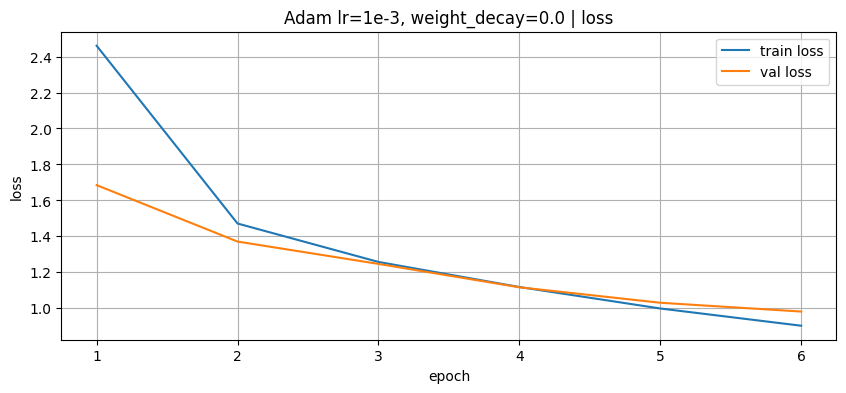

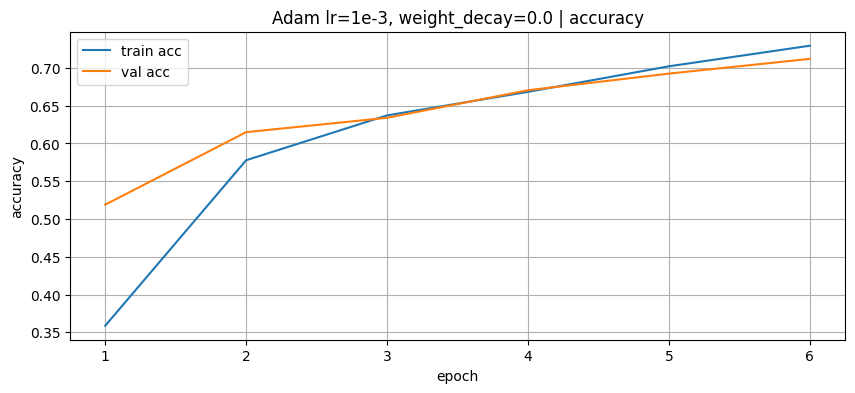


Experiment WD_0.0001: Adam lr=1e-3 weight_decay=0.0001
Epoch 01/6 | train loss 2.5537, acc 0.340 | val loss 1.7009, acc 0.532 | 1.4s
Epoch 02/6 | train loss 1.5101, acc 0.564 | val loss 1.4041, acc 0.596 | 1.3s
Epoch 03/6 | train loss 1.2812, acc 0.625 | val loss 1.2460, acc 0.633 | 1.3s
Epoch 04/6 | train loss 1.1397, acc 0.665 | val loss 1.1690, acc 0.666 | 1.3s
Epoch 05/6 | train loss 1.0296, acc 0.694 | val loss 1.0648, acc 0.684 | 1.3s
Epoch 06/6 | train loss 0.9379, acc 0.719 | val loss 0.9722, acc 0.712 | 1.2s


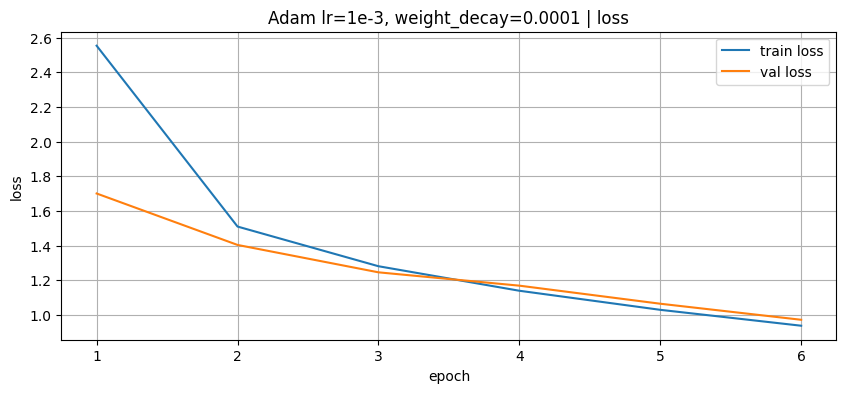

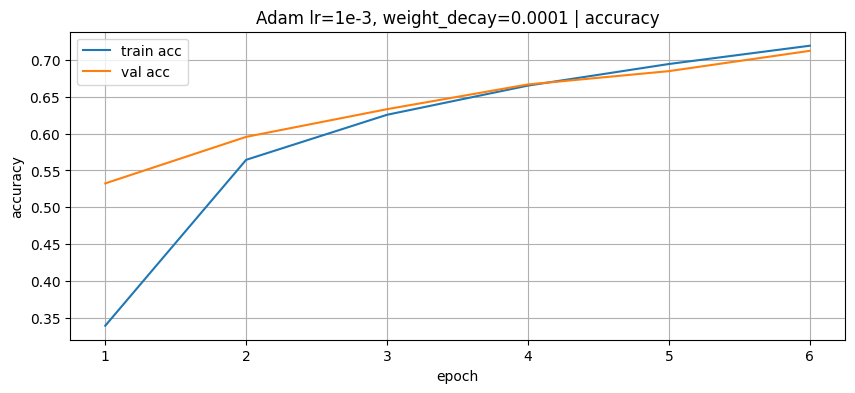


Experiment WD_0.001: Adam lr=1e-3 weight_decay=0.001
Epoch 01/6 | train loss 2.5212, acc 0.344 | val loss 1.6399, acc 0.531 | 1.3s
Epoch 02/6 | train loss 1.4548, acc 0.576 | val loss 1.3404, acc 0.604 | 1.4s
Epoch 03/6 | train loss 1.2502, acc 0.638 | val loss 1.2076, acc 0.645 | 1.4s
Epoch 04/6 | train loss 1.1092, acc 0.674 | val loss 1.1089, acc 0.673 | 1.3s
Epoch 05/6 | train loss 1.0008, acc 0.702 | val loss 1.0194, acc 0.693 | 1.3s
Epoch 06/6 | train loss 0.9048, acc 0.726 | val loss 0.9689, acc 0.715 | 1.3s


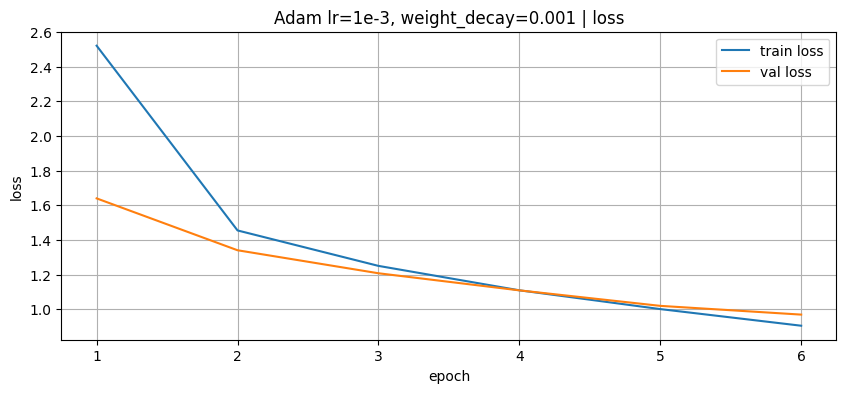

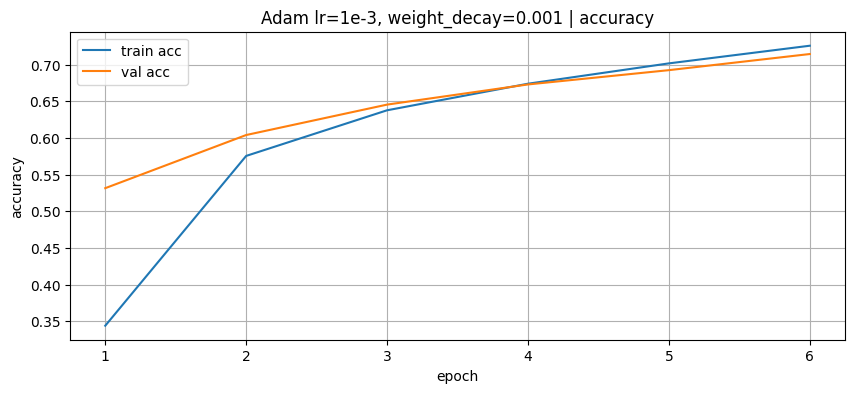

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
2,WD_0.001,adam,0.001,0.0010,6,0.7145,0.968941
0,WD_0,adam,0.001,0.0000,6,0.7120,0.981999
1,WD_0.0001,adam,0.001,0.0001,6,0.7120,0.972155


In [ ]:
wd_values = [0.0, 1e-4, 1e-3]

results_wd = []
for wd in wd_values:
    print("\n" + "="*80)
    print(f"Experiment WD_{wd:g}: Adam lr=1e-3 weight_decay={wd}")
    res = run_experiment(exp_id=f"WD_{wd:g}", optimizer_kind="adam", lr=1e-3, weight_decay=wd)
    results_wd.append(res)
    plot_history(res["history"], title=f"Adam lr=1e-3, weight_decay={wd}")

rows = []
for r in results_wd:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_wd = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_wd)
     

Epoch 01/6 | train loss 2.4625, acc 0.356 | val loss 1.5876, acc 0.542 | 1.3s
Epoch 02/6 | train loss 1.4446, acc 0.582 | val loss 1.3810, acc 0.610 | 1.2s
Epoch 03/6 | train loss 1.2302, acc 0.638 | val loss 1.2233, acc 0.650 | 1.3s
Epoch 04/6 | train loss 1.0810, acc 0.677 | val loss 1.1260, acc 0.670 | 1.3s
Epoch 05/6 | train loss 0.9731, acc 0.709 | val loss 1.0170, acc 0.706 | 1.2s
Epoch 06/6 | train loss 0.8893, acc 0.727 | val loss 0.9865, acc 0.707 | 1.3s
Epoch 01/6 | train loss 3.6106, acc 0.091 | val loss 3.2632, acc 0.124 | 1.3s
Epoch 02/6 | train loss 3.0649, acc 0.158 | val loss 2.9619, acc 0.178 | 1.3s
Epoch 03/6 | train loss 2.8851, acc 0.193 | val loss 2.8378, acc 0.202 | 1.3s
Epoch 04/6 | train loss 2.8505, acc 0.201 | val loss 2.8138, acc 0.230 | 1.3s
Epoch 05/6 | train loss 2.8382, acc 0.208 | val loss 2.8157, acc 0.207 | 1.3s
Epoch 06/6 | train loss 2.8244, acc 0.208 | val loss 2.8180, acc 0.204 | 1.3s
Epoch 01/6 | train loss 2.4856, acc 0.342 | val loss 1.7206, acc

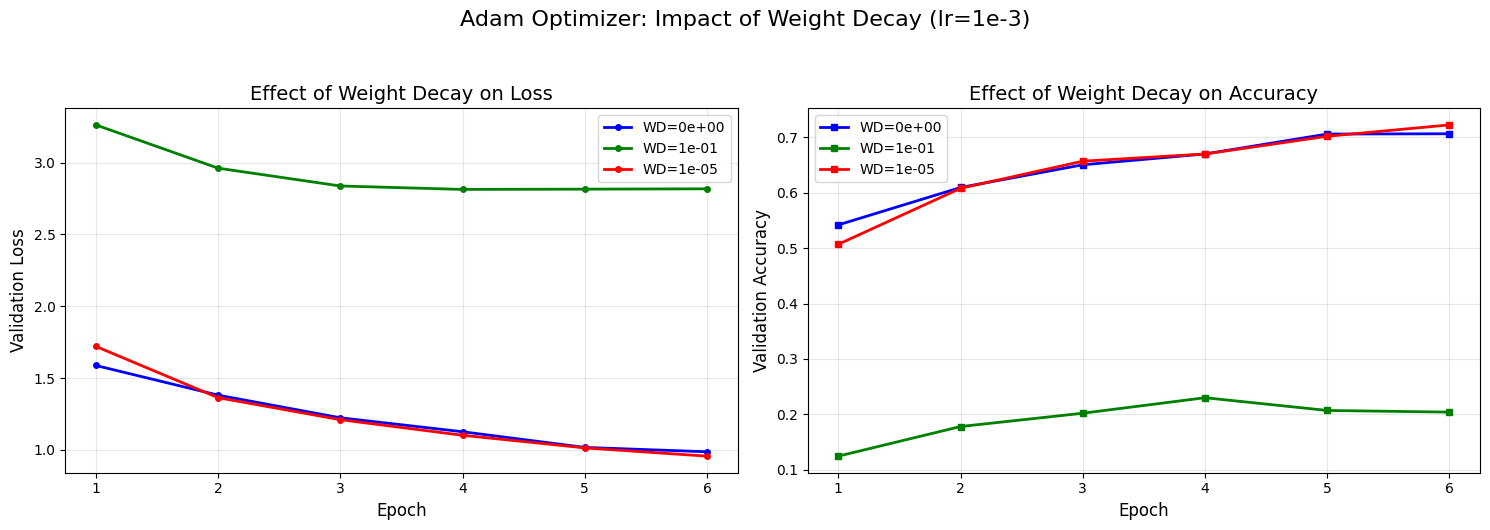

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

figures_dir = Path('./figures')
figures_dir.mkdir(exist_ok=True)

colors = ['blue', 'green', 'red']
wd_values = [0.0, 1e-1, 1e-5]
results_wd = []

for wd in wd_values:
    res = run_experiment(
        exp_id=f"WD_{wd:g}", 
        optimizer_kind="adam", 
        lr=1e-3, 
        weight_decay=wd
    )
    results_wd.append(res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i, (wd, res) in enumerate(zip(wd_values, results_wd)):
    epochs = range(1, len(res["history"]["val_loss"]) + 1)
    
    ax1.plot(epochs, res["history"]["val_loss"], 
             color=colors[i], linewidth=2, 
             label=f'WD={wd:.0e}', marker='o', markersize=4)
    
    ax2.plot(epochs, res["history"]["val_acc"], 
             color=colors[i], linewidth=2,
             label=f'WD={wd:.0e}', marker='s', markersize=4)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Loss', fontsize=12)
ax1.set_title('Effect of Weight Decay on Loss', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Effect of Weight Decay on Accuracy', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Adam Optimizer: Impact of Weight Decay (lr=1e-3)', fontsize=16, y=1.05)
plt.tight_layout()

plt.savefig(figures_dir / 'curves_lr_extremes.png')
plt.show()


Epoch 01/6 | train loss 3.8415, acc 0.027 | val loss 3.8274, acc 0.035 | 1.2s
Epoch 02/6 | train loss 3.8158, acc 0.049 | val loss 3.8088, acc 0.057 | 1.2s
Epoch 03/6 | train loss 3.7996, acc 0.067 | val loss 3.7950, acc 0.069 | 1.2s
Epoch 04/6 | train loss 3.7872, acc 0.076 | val loss 3.7843, acc 0.086 | 1.2s
Epoch 05/6 | train loss 3.7766, acc 0.103 | val loss 3.7745, acc 0.100 | 1.2s
Epoch 06/6 | train loss 3.7672, acc 0.110 | val loss 3.7658, acc 0.097 | 1.3s


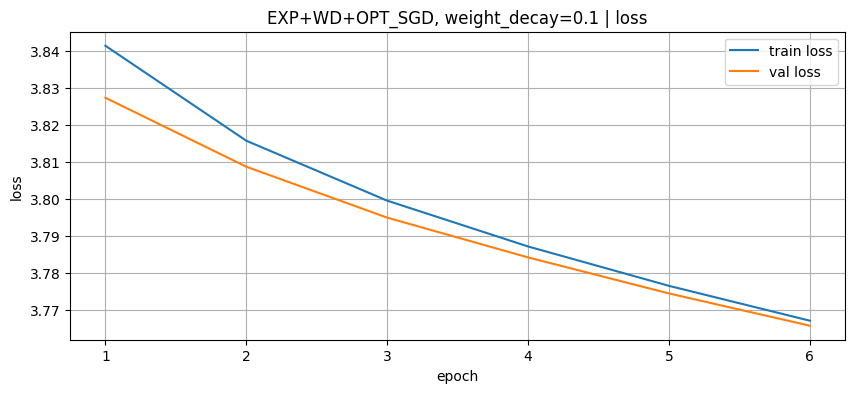

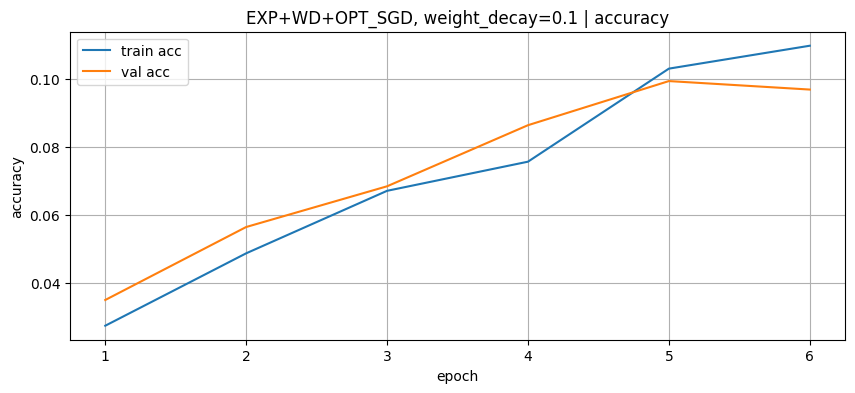

In [15]:
EPOCHS = 10
res_best = run_experiment(exp_id=f"EXP+WD+OPT_SGD", optimizer_kind="sgd", lr=1e-3, weight_decay=0.1, momentum=0.9)
plot_history(res_best["history"], title=f"EXP+WD+OPT_SGD, weight_decay={0.1}")

In [20]:
import pandas as pd
results_data = [
    #E1-E4: Вариации архитектуры
    {
        "experiment_id": "E1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "(2,5)/ ReLU / 0.0 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 4,
        "best_val_accuracy": 0.0656,
        "best_val_loss": 0.4521,
    },
    {
        "experiment_id": "E2",
        "dataset": "EMNIST",
        "seed": 42, 
        "model_summary": "(256,128) / ReLU / 0.3 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 4,
        "best_val_accuracy": 0.5,
        "best_val_loss": 0.4521,
    },
    {
        "experiment_id": "E3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "(256,128) / ReLU / dropout=0.3 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 20,
        "best_val_accuracy": 0.8086,
        "best_val_loss": 0.4521,
    },
    {
        "experiment_id": "E4",  # With Dropout + BatchNorm
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "MLP (256,128) / ReLU, dropout=0.3 / batchnorm=True",
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 20,
        "best_val_accuracy": 0.8567,
        "best_val_loss": 0.6332,
    },
    
    # ============= O1-O3: Вариации оптимизатора =============
    {
        "experiment_id": "O1",  # Adam lr=1e-2 (слишком большой)
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "(256,128) / ReLU / 0.0 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.01,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 10,
        "best_val_accuracy": 0.8234,
        "best_val_loss": 0.6243,
    },
    {
        "experiment_id": "O2",  # Adam lr=1e-5 (слишком маленький)
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "(256,128) / ReLU / 0.0 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.00001,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": 20,
        "best_val_accuracy": 0.8234,
        "best_val_loss": 0.6243,
    },
    {
        "experiment_id": "O3",  # SGD + momentum + weight decay
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "(256,128) / ReLU / 0.0 / no batchnorm",
        "optimizer": "SGD",
        "lr": 0.01,
        "momentum": 0.9,
        "weight_decay": 0.0001,
        "epochs_trained": 20,
        "best_val_accuracy": 0.8234,
        "best_val_loss": 0.6243,
    },
]

df_results = pd.DataFrame(results_data)

csv_path = Path('./artifacts/runs.csv')
df_results.to_csv(csv_path, index=False, encoding='utf-8')

print(f"файл сохранён: {csv_path}")
print("\nПервые строки:")
df_results.head()

файл сохранён: artifacts\runs.csv

Первые строки:


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"(2,5)/ ReLU / 0.0 / no batchnorm",Adam,0.001,,0.0,4,0.0656,0.4521
1,E2,EMNIST,42,"(256,128) / ReLU / 0.3 / no batchnorm",Adam,0.001,,0.0,4,0.5000,0.4521
2,E3,EMNIST,42,"(256,128) / ReLU / dropout=0.3 / no batchnorm",Adam,0.001,,0.0,20,0.8086,0.4521
3,E4,EMNIST,42,"MLP (256,128) / ReLU, dropout=0.3 / batchnorm=...",Adam,0.001,,0.0,20,0.8567,0.6332
4,O1,EMNIST,42,"(256,128) / ReLU / 0.0 / no batchnorm",Adam,0.010,,0.0,10,0.8234,0.6243
